## Sistemas No Lineales: Estados Ligados 
9/04/26
Comenzamos con el caso de gravedad 2D:
$$\vec{F} = - \frac{mMG\vec{r}}{|\vec{r}|^3}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fcl1109 as fc
from matplotlib.animation import FuncAnimation


In [91]:
M = 1
G = 1
def R(x):
    return np.sqrt(x[0] ** 2 + x[1] ** 2)
def f(t, x, n):
    dvxdt = - G * M * x[0] / (R(x) ** n)
    dvydt = - G * M * x[1] / (R(x) ** n)
    dxdt = x[2]
    dydt = x[3]
    return np.array([dxdt, dydt, dvxdt, dvydt], float)

In [92]:
x0 = [0.5, 0, 0, 1.981]  #estado actual: x, y, vx, vy
N = 1000
t0 = 0
tf = 200
h = 0.01
tpoints = np.arange(t0, tf, h)
dim = len(tpoints)
xpoints = np.zeros(dim)
ypoints = np.zeros(dim)
vxpoints = np.zeros(dim)
vypoints = np.zeros(dim)

for i in range(dim):
    xpoints[i] = x0[0]
    ypoints[i] = x0[1]
    vxpoints[i] = x0[2]
    vypoints[i] = x0[3]

    x0 = fc.rk4(tpoints[i], h, x0, lambda t, x: f(t, x, 3))

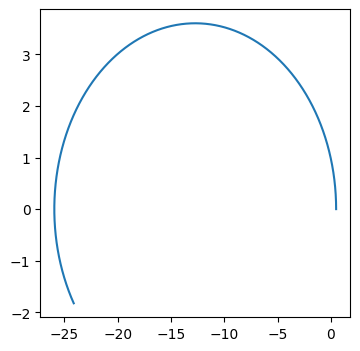

In [93]:
#fig, ax = plt.subplots()
#orbita, = ax.plot(xpoints, ypoints)
fig, ax = plt.subplots(figsize = (4,4))
ax.plot(xpoints, ypoints)

In [ ]:
#Raúl propone
"""
def f_grav(n):
    def fa(t, y):
        r = np.sqrt(y[0] ** 2 + y[2] ** 2)

        Fx = - y [0] / r ** (n + 1)
        Fy = - y[2] / r ** (n + 1)

        return np.array([y[1], Fx, y[3], Fy], float)
    return fa

def simular(y0, h = 0.001, tmax = 20, n = 2):
    y = y0.copy()
    t = 0.0
    N = 4

    Nt = int(tmax / h)
    x = np.zeros(Nt)
    y_pos = np.zeros(Nt)
    f = f_grav(n)

    for i in range(Nt):
        x[i] = y[0]
        y_pos[i] = y[2]

        #y =fc.rk4
        return x, y_pos
"""

NameError: name 'f' is not defined

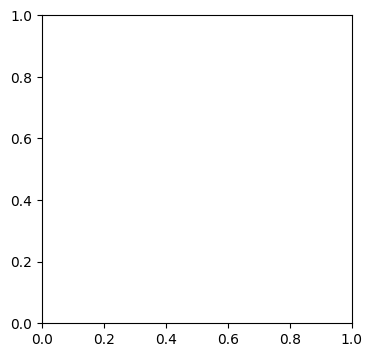

In [2]:
#Caso r^3
x0 = [0.5, 0, 0, 2]  #estado actual: x, y, vx, vy
N = 1000
t0 = 0
tf = 20
h = 0.01

fig, ax = plt.subplots(figsize = (4,4))

def manipulate(y0, n):
    tpoints = np.arange(t0, tf, h)
    dim = len(tpoints)
    xpoints = np.zeros(dim)
    ypoints = np.zeros(dim)
    vxpoints = np.zeros(dim)
    vypoints = np.zeros(dim)
    y = x0.copy()
    for i in range(dim):
        xpoints[i] = y[0]
        ypoints[i] = y[1]
        vxpoints[i] = y[2]
        vypoints[i] = y[3]
    
        y = fc.rk4(tpoints[i], h, y, lambda t, x: f(t, x, n))
    return xpoints, ypoints
x1, y1 = manipulate(x0, 2.005)
x2, y2 = manipulate(x0, 2.1)
x3, y3 = manipulate(x0, 2.3)
x4, y4 = manipulate(x0, 2.4)


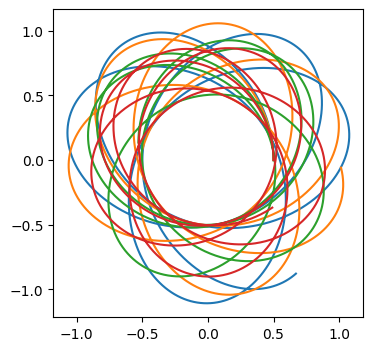

In [109]:
fig, ax = plt.subplots(figsize = (4,4))
#ax.plot(xpoints, ypoints, label = 'n = 2')
ax.plot(x1, y1, label = 'n = 2.005')
ax.plot(x2, y2, label = 'n = 2.1')
ax.plot(x3, y3, label = 'n = 2.3')
ax.plot(x4, y4, label = 'n = 2.4')

## Fuera perturbada
Para obtener una órbita circular, requerimos que la fuerza experimentada sea nula
$$\vec{F} = \left(-\frac{k}{r^2} + \frac{C}{r^3}\right)\hat{r}$$
Con $|C| = l^2/m$, siendo l el momento angular inicial
$$\vec{l} = xv_y\hat{x} - yv_x\hat{y}$$


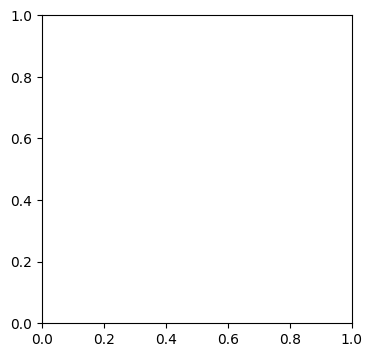

In [25]:
M = 1
G = 1
m = 1

def R(x):
    return np.sqrt(x[0] ** 2 + x[1] ** 2)

def C(x):
    return (m ** 2) * (x[0] * x[3] - x[1] * x[2]) ** 2

def f(t, x, C = 1, k = 1):
    dvxdt = (- k / (R(x) ** 3) + C / (R(x) ** 4)) * x[0]
    dvydt = (- k / (R(x) ** 3) + C / (R(x) ** 4)) * x[1]
    dxdt = x[2]
    dydt = x[3]
    return np.array([dxdt, dydt, dvxdt, dvydt], float)

x0 = [0.5, 0, 1, 1.5]  #estado actual: x, y, vx, vy
Cs = [0.008, 0.03, 0]
N = 10000
t0 = 0
tf = 1000
h = 0.01

fig, ax = plt.subplots(figsize = (4,4))

def manipulate(y0, C):
    tpoints = np.arange(t0, tf, h)
    dim = len(tpoints)
    xpoints = np.zeros(dim)
    ypoints = np.zeros(dim)
    vxpoints = np.zeros(dim)
    vypoints = np.zeros(dim)

    y = x0.copy()

    for i in range(dim):
        xpoints[i] = y[0]
        ypoints[i] = y[1]
        vxpoints[i] = y[2]
        vypoints[i] = y[3]
    
        y = fc.rk4(tpoints[i], h, y, lambda t, x: f(t, x, C))
    return xpoints, ypoints

x1, y1 = manipulate(x0, Cs[0])
x2, y2 = manipulate(x0, Cs[1])
x3, y3 = manipulate(x0, Cs[2])
a = 1

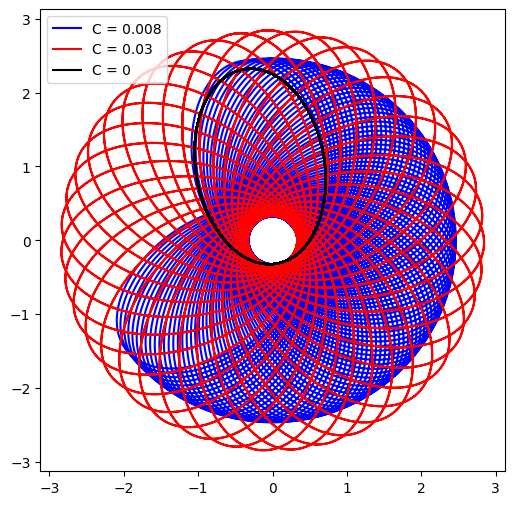

In [26]:
fig, ax = plt.subplots(figsize = (6,6))
ax.plot(x1,y1,label=f'C = {Cs[0]}',color='blue')
ax.plot(x2,y2,label=f'C = {Cs[1]}',color='red')
ax.plot(x3,y3,label=f'C = {Cs[2]}',color='black')
ax.legend()
plt.show()

## Aplicación con potenciales atractivos
$$U(r) = -\frac{k}{r^{n-1}}$$
El resultado analítico es:
$$\Delta\theta = \frac{\pi}{\sqrt{3 - n}}$$
Ocupamos una fuerza conservativa:
$$\vec{F} = -\nabla U(r) = -(n -1) \frac{\vec{r}}{r^{n+1}}$$

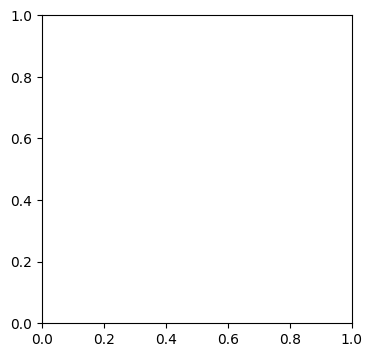

In [38]:
M = 1
G = 1
m = 1
def R(x):
    return np.sqrt(x[0] ** 2 + x[1] ** 2)

def f(t, x, n):
    dvxdt =  - (n - 1) * x[0] / R(x) ** (n + 1)
    dvydt = - (n - 1) * x[1] / R(x) ** (n + 1)
    dxdt = x[2]
    dydt = x[3]
    return np.array([dxdt, dydt, dvxdt, dvydt], float)

x0 = [0.5, 0, 0, 1.5]  #estado actual: x, y, vx, vy
N = 10000
n = [1.5, 2, 2.2, 2.5]
t0 = 0
tf = 100
h = 0.001

fig, ax = plt.subplots(figsize = (4,4))

def manipulate(y0, n):
    tpoints = np.arange(t0, tf, h)
    dim = len(tpoints)
    xpoints = np.zeros(dim)
    ypoints = np.zeros(dim)
    vxpoints = np.zeros(dim)
    vypoints = np.zeros(dim)

    y = x0.copy()

    for i in range(dim):
        xpoints[i] = y[0]
        ypoints[i] = y[1]
        vxpoints[i] = y[2]
        vypoints[i] = y[3]
    
        y = fc.rk4(tpoints[i], h, y, lambda t, x: f(t, x, n))
    return xpoints, ypoints

x1, y1 = manipulate(x0, n[0])
x2, y2 = manipulate(x0, n[1])
x3, y3 = manipulate(x0, n[2])
x4,y4 = manipulate(x0, n[3])
a = 1

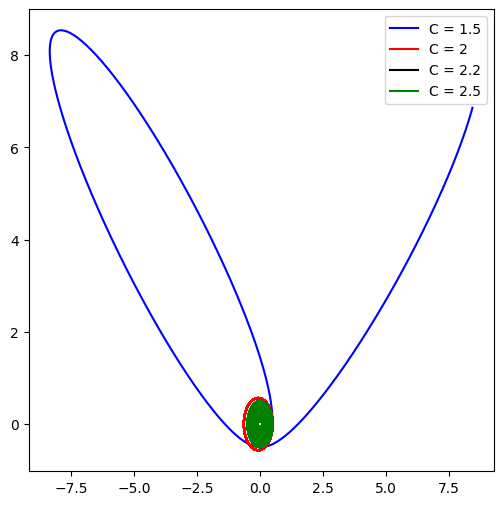

In [39]:
fig, ax = plt.subplots(figsize = (6,6))
ax.plot(x1,y1,label=f'C = {n[0]}',color='blue')
ax.plot(x2,y2,label=f'C = {n[1]}',color='red')
ax.plot(x3,y3,label=f'C = {n[2]}',color='black')
ax.plot(x4,y4,label=f'C = {n[3]}',color='green')
ax.legend()
plt.show()